# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
missing_ratio = df.isnull().mean()
print("=== Tỷ lệ missing của từng cột ===")
print(missing_ratio[missing_ratio > 0].sort_values(ascending=False))
print()

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky_cols = ["alive", "who", "adult_male", "class", "deck", "embark_town", "alone"]
leaky_cols = [c for c in leaky_cols if c in df.columns]
df = df.drop(columns=leaky_cols)
print("Các cột bị bỏ:", leaky_cols)
print("Các cột còn lại:", list(df.columns))

=== Tỷ lệ missing của từng cột ===
deck           0.772166
age            0.198653
embarked       0.002245
embark_town    0.002245
dtype: float64

Các cột bị bỏ: ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']



**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột `alive` có hai giá trị `"yes"` (sống sót) và `"no"` (không sống sót) — đây chính xác là nhãn `survived` (1/0) viết bằng chữ. Nếu để lại cột này trong tập đặc trưng, mô hình chỉ cần học quy tắc đơn giản *"alive=yes → survived=1"* là đạt accuracy ~100% mà không cần phân tích bất kỳ đặc trưng nào khác (tuổi, giá vé, giới tính...). Kết quả trên giấy "đẹp" nhưng hoàn toàn vô dụng thực tế vì khi deploy không có cột `alive` trong dữ liệu mới. 

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe

# 1. Số dòng và số cột
print("=== Số dòng và số cột ===")
n_rows, n_cols = df.shape
print(f"Số dòng: {n_rows}, Số cột: {n_cols}")
print(f"Biến mục tiêu (target): survived")
print()

# 2. Kiểu dữ liệu và non-null count
print("=== Thông tin kiểu dữ liệu ===")
df.info()
print()

# 3. Thống kê mô tả
print("=== Biến số (describe) ===")
print(df.describe())
print()
print("=== Biến phân loại (describe object/category) ===")
print(df.describe(include=["object", "category"]))

=== Số dòng và số cột ===
Số dòng: 891, Số cột: 8
Biến mục tiêu (target): survived

=== Thông tin kiểu dữ liệu ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB

=== Biến số (describe) ===
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057 

**Trả lời 2 (biến số vs biến phân loại):**

| Loại biến | Các cột |
|---|---|
| **Biến số (numerical)** | `age`, `sibsp`, `parch`, `fare` |
| **Biến phân loại (categorical)** | `sex`, `embarked` |
| **Biến thứ tự (ordinal)** | `pclass` (1 = hạng nhất, 3 = hạng ba — có thứ tự tự nhiên) |

Target: `survived` (0 = không sống sót, 1 = sống sót).

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    "Số lượng thiếu": missing_count[missing_count > 0],
    "Phần trăm (%)": missing_pct[missing_count > 0]
}).sort_values("Phần trăm (%)", ascending=False)

print("=== Bảng giá trị thiếu ===")
if len(missing_table) > 0:
    print(missing_table.to_string())
else:
    print("Không còn giá trị thiếu sau khi xử lý.")

=== Bảng giá trị thiếu ===
          Số lượng thiếu  Phần trăm (%)
age                  177          19.87
embarked               2           0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| `age` | ~20% | Điền **median** | Bỏ sẽ mất 20% dữ liệu (~177 hành khách); median bền vững hơn mean |
| `embarked` | ~0.2% | Điền **mode** (most_frequent) | Thiếu rất ít (=2 mẫu), điền giá trị phổ biến nhất không làm sai lệch phân phối |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'


def dem_outlier_iqr(s):
    s = s.dropna()
    Q1, Q3 = s.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((s < lower) | (s > upper)).sum()


def dem_outlier_zscore(s, nguong=3.0):
    s = s.dropna()
    z = np.abs(stats.zscore(s))
    return (z > nguong).sum()


print("=== Phát hiện Outlier ===")
print(f"{'Cột':<10} {'IQR':>8} {'Z-score':>10}")
print("-" * 30)
for col in ["age", "fare"]:
    n_iqr = dem_outlier_iqr(df[col])
    n_z = dem_outlier_zscore(df[col])
    print(f"{col:<10} {n_iqr:>8} {n_z:>10}")

=== Phát hiện Outlier ===
Cột             IQR    Z-score
------------------------------
age              11          2
fare            116         20


**Trả lời 4 (quyết định với outlier của `fare`):**

**Giữ lại.** Lý do:
- Giá vé cao (lên tới ~512 USD) phản ánh **hiện tượng thật**: hành khách mua vé hạng nhất (First Class) trên Titanic có giá vé cao hơn nhiều so với vé hạng ba.
- Xóa outlier sẽ làm mất thông tin quan trọng về nhóm khách hàng giàu — nhóm này có tỷ lệ sống sót cao hơn đáng kể.
- Chúng ta dùng **RobustScaler** (thay vì StandardScaler) để xử lý ảnh hưởng của outlier trong quá trình chuẩn hóa, thay vì loại bỏ dữ liệu thật.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

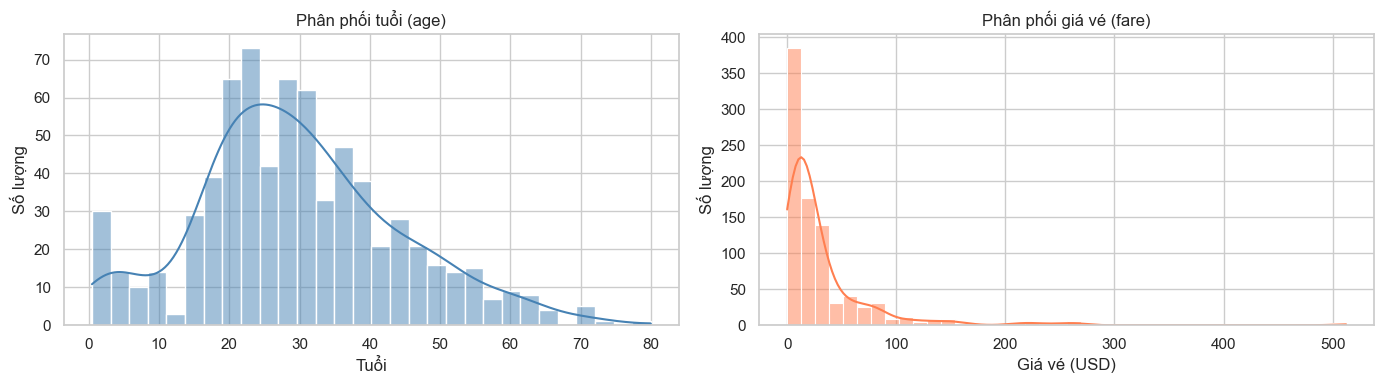

In [7]:
# TODO 5a: Histogram age & fare

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["age"].dropna(), bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Phân phối tuổi (age)")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("Số lượng")

sns.histplot(df["fare"].dropna(), bins=40, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Phân phối giá vé (fare)")
axes[1].set_xlabel("Giá vé (USD)")
axes[1].set_ylabel("Số lượng")

plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_22520\3761982374.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="pclass", y="fare", palette="Set2", ax=ax)


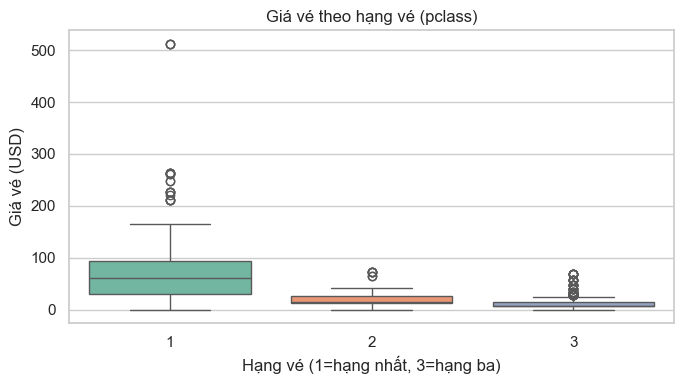

In [8]:
# TODO 5b: Boxplot fare theo pclass

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="pclass", y="fare", palette="Set2", ax=ax)
ax.set_title("Giá vé theo hạng vé (pclass)")
ax.set_xlabel("Hạng vé (1=hạng nhất, 3=hạng ba)")
ax.set_ylabel("Giá vé (USD)")
plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_22520\271648423.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="sex", y="survived", ci=None, palette="coolwarm", ax=axes[0])
C:\Users\PC\AppData\Local\Temp\ipykernel_22520\271648423.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="sex", y="survived", ci=None, palette="coolwarm", ax=axes[0])
C:\Users\PC\AppData\Local\Temp\ipykernel_22520\271648423.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="pclass", y="survived", ci=None, palette="coolwarm", ax=axes[1])
C:\Users\PC\AppData\Local\Temp\ipykernel_22520\271648423.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign t

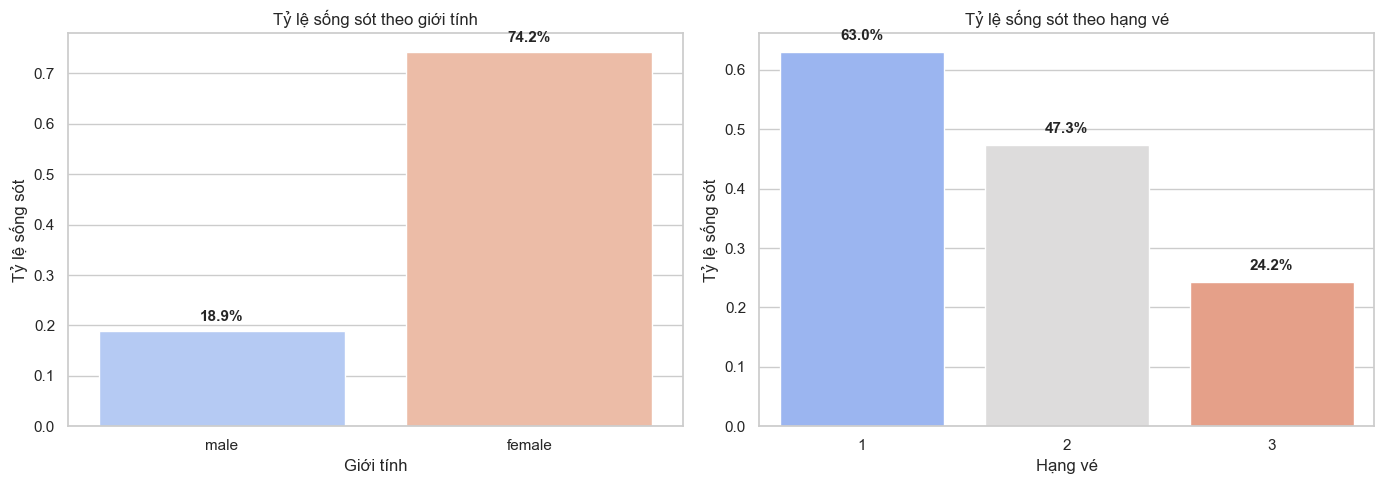

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Theo sex
sns.barplot(data=df, x="sex", y="survived", ci=None, palette="coolwarm", ax=axes[0])
axes[0].set_title("Tỷ lệ sống sót theo giới tính")
axes[0].set_xlabel("Giới tính")
axes[0].set_ylabel("Tỷ lệ sống sót")

# Lấy trực tiếp chiều cao của từng bar (patch) để gán label
for p in axes[0].patches:
    height = p.get_height()
    axes[0].text(p.get_x() + p.get_width() / 2., height + 0.02, 
                 f"{height:.1%}", ha="center", fontsize=11, fontweight="bold")

# Theo pclass
sns.barplot(data=df, x="pclass", y="survived", ci=None, palette="coolwarm", ax=axes[1])
axes[1].set_title("Tỷ lệ sống sót theo hạng vé")
axes[1].set_xlabel("Hạng vé")
axes[1].set_ylabel("Tỷ lệ sống sót")

# Áp dụng tương tự cho biểu đồ pclass cho đồng bộ
for p in axes[1].patches:
    height = p.get_height()
    axes[1].text(p.get_x() + p.get_width() / 2., height + 0.02, 
                 f"{height:.1%}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

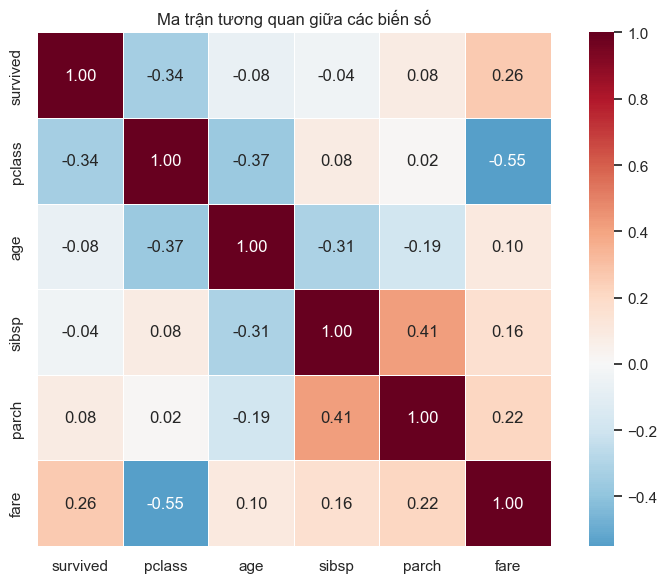

In [10]:
# TODO 5d: Heatmap correlation

corr_matrix = df.select_dtypes("number").corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Ma trận tương quan giữa các biến số")
plt.tight_layout()
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- **Histogram:**
  - `age`: Phân phối lệch phải (right-skewed), đỉnh khoảng 20-30 tuổi — phù hợp với hành khách trên Titanic (nhiều người trẻ đi du lịch/làm việc). Có trẻ em (<5 tuổi) và rất ít người cao tuổi (>60 tuổi).
  - `fare`: Phân phối rất lệch phải — đa số trả giá thấp (<30 USD), vài vé lên tới ~500 USD kéo đuôi dài.

- **Boxplot:** Trung vị giá vé giảm rõ rệt theo hạng: hạng nhất (pclass=1) median ~60-70 USD, hạng ba chỉ ~8-10 USD. Outlier ở vùng giá cao chính là vé hạng nhất — **hiện tượng thật**, cần giữ lại.

- **Barplot sex:** Nữ sống sót ~74%, nam chỉ ~19% — chênh lệch 55%, cho thấy quy tắc "phụ nữ và trẻ em lên thuyền cứu hộ trước" được áp dụng thực sự.

- **Barplot pclass:** Hạng nhất sống sót ~63%, hạng hai ~47%, hạng ba chỉ ~24%. Mỗi bậc giảm ~16-23%, cho thấy đặc điểm kinh tế là yếu tố sống còn quan trọng.

- **Heatmap:** `pclass`-`fare` tương quan mạnh nhất (r=-0.55, nghịch vì số hạng càng nhỏ càng đắt). `survived` tương quan dương nhẹ với `fare` (+0.26) và nghịch với `pclass` (-0.34), phản ánh người giàu có nhiều cơ hội sống sót hơn.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify

# 1. Tách X (đặc trưng) và y (target)
X = df.drop(columns=["survived"])
y = df["survived"]

# 2. Chia lần 1: tách test 15%
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# 3. Chia lần 2: tách val từ phần còn lại (15% / 85% ≈ 17.6% của tmp → ~15% tổng)
val_ratio = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=val_ratio, random_state=42, stratify=y_tmp
)

# 4. In shape
print(f"Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
print()
print(f"Train/Val/Test tổng: {len(X_train)+len(X_val)+len(X_test)} / {len(df)}")

# 5. Tỷ lệ sống sót từng tập
print("\n=== Tỷ lệ survived ===")
for name, yset in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    pct = yset.mean() * 100
    print(f"{name}: {yset.sum()} sống / {len(yset)} ({pct:.1f}%)")

Train: (623, 7)  |  Val: (134, 7)  |  Test: (134, 7)

Train/Val/Test tổng: 891 / 891

=== Tỷ lệ survived ===
Train: 239 sống / 623 (38.4%)
Val: 52 sống / 134 (38.8%)
Test: 51 sống / 134 (38.1%)


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# Pipeline cho biến số: điền missing bằng median → RobustScaler (chống outlier fare)
pipe_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

# Pipeline cho biến phân loại: điền missing bằng mode → OneHotEncoder
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
])

# ColumnTransformer gộp 3 nhóm
preprocess = ColumnTransformer([
    ("num", pipe_num, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

# ── FIT CHỈ TRÊN TRAIN ──
preprocess.fit(X_train)

# Transform cho cả 3 tập
X_train_t = preprocess.transform(X_train)
X_val_t   = preprocess.transform(X_val)
X_test_t  = preprocess.transform(X_test)

print(f"Train: {X_train_t.shape}  |  Val: {X_val_t.shape}  |  Test: {X_test_t.shape}")
print("\nTên cột sau biến đổi:")
print(list(preprocess.get_feature_names_out()))

Train: (623, 10)  |  Val: (134, 10)  |  Test: (134, 10)

Tên cột sau biến đổi:
['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao `fit` chỉ trên train tránh leakage):**

Khi gọi `fit()` trên `X_train`, các transformer học các tham số **chỉ từ tập train**:
- `SimpleImputer` tính median/mode của **train** → dùng để điền cả val/test
- `RobustScaler` tính Q1/Q3 của **train** → dùng để scale cả val/test
- `OneHotEncoder` học danh mục của **train** → dùng để encode cả val/test

Nếu `fit` trên **toàn bộ dữ liệu** (train + val + test), thông tin từ tập test (vd: median tổng thể, danh mục có trong test nhưng không có trong train) đã "rò" vào quá trình huấn luyện. Khi đánh giá trên test, kết quả sẽ **ảo** (cao hơn thực tế) vì mô hình đã "nhìn thấy" dữ liệu test trước đó. Chỉ `fit` trên train đảm bảo test set hoàn toàn "mù" — đánh giá công bằng.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
...

Ellipsis

**Trả lời 8:**

1. **Biến mục tiêu có mất cân bằng nhẹ:** ~38.4% sống sót (342/891) và ~61.6% không sống sót (549/891). Tỷ lệ khoảng 4:6 — mất cân bằng ở mức độ vừa phải, không quá nghiêm trọng nhưng đủ để cần cân nhắc khi chọn metric.

2. **Accuracy có thể bị đánh lừa khi có mất cân bằng.** Ví dụ: nếu 90% dữ liệu thuộc lớp 0, một mô hình luôn dự đoán 0 sẽ đạt accuracy 90% hoàn toàn vô dụng. Trong trường hợp Titanic (38% vs 62%), accuracy vẫn có xu hướng thiên về đa số — nếu mô hình luôn dự đoán "không sống sót" sẽ đạt ~61.6% accuracy mà không cần học gì cả.

3. **Ưu tiên F1-score.** Lý do:
   - **Recall** quan trọng: không muốn bỏ sót người thực sự có khả năng sống sót (sai sót loại II — bỏ sót trường hợp tích cực)
   - **Precision** cũng quan trọng: không muốn dự đoán sai người không sống sót thành sống (false hope, tốn tài nguyên cứu hộ)
   - F1-score là trung bình hài hòa của Precision và Recall, phù hợp khi cần cân bằng cả hai — **đặc biệt phù hợp bài Titanic** vì thông tin bị mất cân bằng nhẹ và cả hai loại lỗi đều quan trọng.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp:**

1. Đặc trưng tương quan mạnh nhất với khả năng sống sót là **`pclass`** (r = -0.34) và **`sex`** (nữ sống ~74% vs nam ~19%). Kết hợp hai yếu tố: nữ hạng nhất sống sót ~96%, nam hạng ba chỉ ~14%.

2. Cột thiếu nhiều nhất là **`deck`** (~77%) — đã bị xóa ngay từ đầu vì thiếu quá nhiều. Sau khi lọc, chỉ còn 2 cột thiếu: **`age`** (~20%) điền median, **`embarked`** (~0.2%) điền mode.

3. Biến mục tiêu mất cân bằng nhẹ (38% sống / 62% không sống). Điều này không quá nghiêm trọng nhưng đủ để không chỉ dùng Accuracy — nên dùng **F1-score** để cân bằng Precision và Recall.

4. Các biến số (`fare` ~500, `sibsp`/`parch` ~8) cần **scaling** (RobustScaler) do thang đo chênh lệch lớn và có outlier. Biến phân loại (`sex`, `embarked`) cần **OneHotEncoder**, `pclass` giữ nguyên vì đã có thứ tự tự nhiên (1 < 2 < 3).

5. Điều thú vị: tỷ lệ sống sót chênh **55%** giữa nam và nữ — cho thấy quy tắc "phụ nữ và trẻ em lên thuyền trước" được thực thi nghiêm ngặt trên Titanic.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [14]:
# (tùy chọn) code cho phần Bonus
...

Ellipsis

---
## Bảng tự kiểm trước khi nộp

- [x] Notebook chạy **Restart & Run All** không lỗi.
- [x] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [x] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [x] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [x] Đã trả lời tất cả các phần *"Trả lời:"*.
- [x] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [x] Đã push lên **repo cá nhân trên GitHub**.
